# Notebook Objective -  Visualize Movement from Spawning Grounds

In [20]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import matplotlib.ticker as ticker

import seaborn as sns
from shapely.geometry import Point, Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import imageio

import cmocean
import cmocean.cm as cmo
import importlib
import utils  # Importing the utils module
import cbmaps


In [21]:
importlib.reload(utils)
# Import necessary data and functions from utils
hypotheses = utils.hypotheses
stages = utils.stages
locations = utils.locations
start_years = utils.start_years
months_data = utils.months_data
extents = utils.extents

#function
plot_region = utils.plot_region
plot_contour = utils.plot_contour
plot_nurs_color = utils.plot_nurseries_color
plot_nurs_colorfill = utils.plot_nurseries_colorfill
plot_nurs_bw = utils.plot_nurseries_bw
plot_nurs_bwfill = utils.plot_nurseries_bw_fill

plot_mgmt = utils.plot_mgmt

In [22]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need
# necessary data and functions from utils
locations = utils.locations
boxes = {key: value['boxes'] for key, value in locations.items()}
location_labels = {key: value['label'] for key, value in locations.items()}
location_colors = {key: value['color'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

months = utils.months_data
month_colors = {key: value['color'] for key, value in months.items()}
month_labels = {key: value['label'] for key, value in months.items()}
month_order = {key: value['order'] for key, value in months.items()}

stages = utils.stages
stage_colors = {key: value['color'] for key, value in stages.items()}
stage_labels = {key: value['label'] for key, value in stages.items()}
stage_markers = {key: value['marker'] for key, value in stages.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

# Management Area
munits = utils.mu_strata
mu_bounds = {key: value['boxes'] for key, value in munits.items()}
location_labels = {key: value['name'] for key, value in munits.items()}

start_years = utils.start_years

In [4]:
extent = extents['hires']

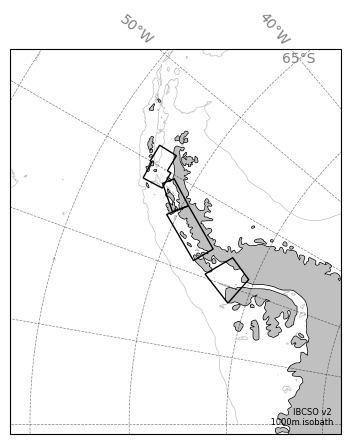

In [11]:
# Test if it worked
# Create the figure and subplots for the facet plot (one for each year)
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.SouthPolarStereo()})
extent = extents['hires']
plot_region(ax, extent)
plot_contour(ax, extent)
# plot_mgmt(ax, extent, mu_bounds)
plot_nurs_bw(ax, extent, locations)

# Load Data

In [12]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
output_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/processed_data/'
fig_path = repo_path + 'figures/path-plots/'
tab_path = repo_path + 'figures/tables/'

In [13]:
summary_file = 'nursery_use_summary.csv'
start_file = 'IDLloc_spawning_21dfilter.csv'
traj_file = 'processed_trajectories_21dfilter.csv'

summary=pd.read_csv(output_path + summary_file) 

starting_location_df=pd.read_csv(output_path + start_file) 

df_traj=pd.read_csv(output_path + traj_file) 

# Plot By Age

In [63]:
def plot_routes_by_age(stage_df, months, extent, hypothesis, start_year, save_path=None):
    # Create a single plot
    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
    # Set the map background to dark grey
    ax.set_facecolor('#e0e0e3')# gainsboro')  # You can adjust this color if needed    
    # Plot the base map
    plot_region(ax, extent)
    plot_contour(ax, extent)
    plot_nurs_bw(ax, extent, locations)
    
    # Plot the trajectory for each larva, color-coded by age (stage)
    for larval_id in stage_df['larval_id'].unique():
        larval_trajectory = stage_df[stage_df['larval_id'] == larval_id]
        for age in larval_trajectory['stage'].unique():
            age_data = larval_trajectory[larval_trajectory['stage'] == age]
            ax.plot(age_data['lon'], age_data['lat'], 
                    color=stage_colors[age], alpha=0.5, linewidth=2, transform=ccrs.PlateCarree())  # Increased alpha and linewidth
    
    # Combine the annotation into a single box with bold and regular text
    annotation_text = (
        'Model Configuration:\n'
        f'{hypothesis_labels[hypothesis]} Simulation\n'
        f'Initialized: {start_year}'
    )
    ax.annotate(annotation_text,
                xy=(0.05, 0.05), xycoords='axes fraction', fontsize=12,
                horizontalalignment='left', verticalalignment='bottom', bbox=dict(facecolor='white', alpha=0.7))

    # Get the name of the first month (since we are plotting for one month at a time)
    month_name = month_labels[months[0]] if len(months) == 1 else "Multiple Months"
    
    # Add legend for ages with updated title reflecting the month name
    age_legend_handles = [Line2D([0], [0], color=stage_colors[s], lw=2, label=stage_labels[s]) for s in stages]
    ax.legend(handles=age_legend_handles, title=f'Transit in {month_name}', loc='upper left')
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save plot if save_path is specified
    if save_path:
        plt.savefig(fig_path+save_path, dpi=200, bbox_inches='tight', pad_inches=0)
    
    # Show plot
    plt.close()
    # plt.show()

In [61]:
# Modified Pre-processing function for debugging
def preprocess_data(df, start_year, hypothesis, stage, months):
    print(f"Filtering for start_year: {start_year}, hypothesis: {hypothesis}, stage: {stage}, months: {months}")
    
    # Step 1: Filter by start year and hypothesis
    subset_df = df[(df['start_year'] == start_year) & (df['hypothesis'] == hypothesis)]
    print(f"Data after filtering by start_year and hypothesis: {subset_df.shape}")
    
    # Step 2: Filter by stage (if provided)
    if stage is not None:
        stage_df = subset_df[subset_df['stage'] == stage].copy()
    else:
        stage_df = subset_df.copy()  # No filtering by stage
    print(f"Data after filtering by stage: {stage_df.shape}")
    
    # Step 3: Extract month from 'date' and filter by selected months
    stage_df.loc[:, 'month'] = pd.to_datetime(stage_df['date']).dt.month
    stage_df = stage_df[stage_df['month'].isin(months)]
    print(f"Data after filtering by months: {stage_df.shape}")
    
    return stage_df

In [69]:
# # Check the unique months present in the dataset
# print("Unique months in the dataset:")
# print(df_traj['date'].apply(lambda x: pd.to_datetime(x).month).unique())

# # Filter data for the selected months and display basic info
# selected_months = [11, 12, 1, 2, 3, 4, 5, 6]
# df_test = df_traj[df_traj['date'].apply(lambda x: pd.to_datetime(x).month).isin(selected_months)]

# print("\nData available for the selected months:")
# print(df_test['month'].value_counts())

# # Display the first few rows of the filtered dataset
# print("\nSample data for the selected months:")
# print(df_test.head())

In [23]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_ice'

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'routes_by_age_{SY}_{hyp}_month[{month}-ptol].png'
        
        # Pre-process data for the selected month
        df_to_plot = preprocess_data(df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month])  # Filter by the specific month
        
        # Plot trajectories for the month, colored by age
        plot_routes_by_age(df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, save_path=save_path)

Filtering for start_year: 2016, hypothesis: h_ice, stage: None, months: [11]
Data after filtering by start_year and hypothesis: (54000, 16)
Data after filtering by stage: (54000, 16)
Data after filtering by months: (1166, 17)
Filtering for start_year: 2016, hypothesis: h_ice, stage: None, months: [12]
Data after filtering by start_year and hypothesis: (54000, 16)
Data after filtering by stage: (54000, 16)
Data after filtering by months: (3531, 17)
Filtering for start_year: 2016, hypothesis: h_ice, stage: None, months: [1]
Data after filtering by start_year and hypothesis: (54000, 16)
Data after filtering by stage: (54000, 16)
Data after filtering by months: (5801, 17)
Filtering for start_year: 2016, hypothesis: h_ice, stage: None, months: [2]
Data after filtering by start_year and hypothesis: (54000, 16)
Data after filtering by stage: (54000, 16)
Data after filtering by months: (6750, 17)
Filtering for start_year: 2016, hypothesis: h_ice, stage: None, months: [3]
Data after filtering b

In [24]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_null'

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'routes_by_age_{SY}_{hyp}_month[{month}-ptol].png'
        
        # Pre-process data for the selected month
        df_to_plot = preprocess_data(df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month])  # Filter by the specific month
        
        # Plot trajectories for the month, colored by age
        plot_routes_by_age(df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, save_path=save_path)

Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [11]
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (1478, 17)
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [12]
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (3883, 17)
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [1]
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (6061, 17)
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [2]
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (6846, 17)
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [3]
Data after filter

In [25]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_dvm'

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'routes_by_age_{SY}_{hyp}_month[{month}-ptol].png'
        
        # Pre-process data for the selected month
        df_to_plot = preprocess_data(df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month])  # Filter by the specific month
        
        # Plot trajectories for the month, colored by age
        plot_routes_by_age(df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, save_path=save_path)

Filtering for start_year: 2016, hypothesis: h_dvm, stage: None, months: [11]
Data after filtering by start_year and hypothesis: (82980, 16)
Data after filtering by stage: (82980, 16)
Data after filtering by months: (2024, 17)
Filtering for start_year: 2016, hypothesis: h_dvm, stage: None, months: [12]
Data after filtering by start_year and hypothesis: (82980, 16)
Data after filtering by stage: (82980, 16)
Data after filtering by months: (5659, 17)
Filtering for start_year: 2016, hypothesis: h_dvm, stage: None, months: [1]
Data after filtering by start_year and hypothesis: (82980, 16)
Data after filtering by stage: (82980, 16)
Data after filtering by months: (8833, 17)
Filtering for start_year: 2016, hypothesis: h_dvm, stage: None, months: [2]
Data after filtering by start_year and hypothesis: (82980, 16)
Data after filtering by stage: (82980, 16)
Data after filtering by months: (10508, 17)
Filtering for start_year: 2016, hypothesis: h_dvm, stage: None, months: [3]
Data after filtering 

In [26]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_size'

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'routes_by_age_{SY}_{hyp}_month[{month}-ptol].png'
        
        # Pre-process data for the selected month
        df_to_plot = preprocess_data(df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month])  # Filter by the specific month
        
        # Plot trajectories for the month, colored by age
        plot_routes_by_age(df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, save_path=save_path)

Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [11]
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (11926, 17)
Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [12]
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (33161, 17)
Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [1]
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (55851, 17)
Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [2]
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (68806, 17)
Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [3]
Data 

# Isolate Nursery Grounds


In [65]:
# Modified Pre-processing function for debugging
def preprocess_data_loc(df, start_year, hypothesis, stage, months, idl_loc=None):
    print(f"Filtering for start_year: {start_year}, hypothesis: {hypothesis}, stage: {stage}, months: {months}, IDL_loc: {idl_loc}")

    # Step 1: Filter by start year and hypothesis
    subset_df = df[(df['start_year'] == start_year) & (df['hypothesis'] == hypothesis)]
    print(f"Data after filtering by start_year and hypothesis: {subset_df.shape}")

    # Step 2: Filter by stage (if provided)
    if stage is not None:
        stage_df = subset_df[subset_df['stage'].isin(stage)].copy()
    else:
        stage_df = subset_df.copy()  # No filtering by stage
    print(f"Data after filtering by stage: {stage_df.shape}")

    # Step 3: Extract month from 'date' and filter by selected months
    stage_df.loc[:, 'month'] = pd.to_datetime(stage_df['date']).dt.month
    stage_df = stage_df[stage_df['month'].isin(months)]
    print(f"Data after filtering by months: {stage_df.shape}")

    # Step 4: Filter by IDL_loc (if provided)
    if idl_loc is not None:
        stage_df = stage_df[stage_df['IDL_loc'] == idl_loc]
        print(f"Data after filtering by IDL_loc '{idl_loc}': {stage_df.shape}")

    return stage_df

In [68]:

def plot_routes_by_age(stage_df, months, extent, hypothesis, start_year, idl_loc=None, save_path=None):
    # Create a single plot
    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
    
    # Set the map background to dark grey
    ax.set_facecolor('#e0e0e3')  # You can adjust this color if needed    
    
    # Plot the base map
    plot_region(ax, extent)
    plot_contour(ax, extent)
    plot_nurs_bw(ax, extent, locations)
    
    # Plot the trajectory for each larva, color-coded by age (stage)
    for larval_id in stage_df['larval_id'].unique():
        larval_trajectory = stage_df[stage_df['larval_id'] == larval_id]
        for age in larval_trajectory['stage'].unique():
            age_data = larval_trajectory[larval_trajectory['stage'] == age]
            ax.plot(age_data['lon'], age_data['lat'], 
                    color=stage_colors[age], alpha=0.5, linewidth=2, transform=ccrs.PlateCarree())
    
    # Combine the annotation into a single box with bold and regular text
    location_name = f"Location: {idl_loc}" if idl_loc else "All Locations"
    annotation_text = (
        'Model Configuration:\n'
        f'{hypothesis_labels[hypothesis]} Simulation\n'
        f'Initialized: {start_year}\n'
        f'{location_name}'
    )
    ax.annotate(annotation_text,
                xy=(0.05, 0.05), xycoords='axes fraction', fontsize=12,
                horizontalalignment='left', verticalalignment='bottom', 
                bbox=dict(facecolor='white', alpha=0.7))

    # Get the name of the first month (since we are plotting for one month at a time)
    month_name = month_labels[months[0]] if len(months) == 1 else "Multiple Months"
    
    # Add legend for ages with updated title reflecting the month name
    age_legend_handles = [
        Line2D([0], [0], color=stage_colors[s], lw=2, label=stage_labels[s]) 
        for s in stages
    ]
    ax.legend(handles=age_legend_handles, title=f'Transit in {month_name}', loc='upper left')
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save plot if save_path is specified
    if save_path:
        plt.savefig(fig_path + save_path, dpi=200, bbox_inches='tight', pad_inches=0)
        print(f"Plot saved to: {fig_path + save_path}")

    # Close plot to free memory
    plt.close()


### RUN IT

In [78]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_size'
idl_loc = 'BS'  # Example location to filter

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'by-ng/routes-by-age-and-loc-{hyp}/{idl_loc}-routes_by_age_{SY}_{hyp}_month[{month}].png'

        # Pre-process data for the selected month and location
        df_to_plot = preprocess_data_loc(
            df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month], idl_loc=idl_loc
        )

        # Plot trajectories for the month, colored by age, and save the plot
        plot_routes_by_age(
            df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, 
            idl_loc=idl_loc, save_path=save_path
        )

Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [11], IDL_loc: BS
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (11926, 17)
Data after filtering by IDL_loc 'BS': (4184, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_size/BS-routes_by_age_2016_h_size_month[11].png
Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [12], IDL_loc: BS
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (33161, 17)
Data after filtering by IDL_loc 'BS': (10325, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_size/BS-routes_by_age_2016_h_size_month[12].png
Filtering for start_year: 2016, hypothesis: h_size, stage: None, 

In [79]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_size'
idl_loc = 'MB2'  # Example location to filter

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'by-ng/routes-by-age-and-loc-{hyp}/{idl_loc}-routes_by_age_{SY}_{hyp}_month[{month}].png'

        # Pre-process data for the selected month and location
        df_to_plot = preprocess_data_loc(
            df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month], idl_loc=idl_loc
        )

        # Plot trajectories for the month, colored by age, and save the plot
        plot_routes_by_age(
            df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, 
            idl_loc=idl_loc, save_path=save_path
        )

Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [11], IDL_loc: MB2
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (11926, 17)
Data after filtering by IDL_loc 'MB2': (3182, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_size/MB2-routes_by_age_2016_h_size_month[11].png
Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [12], IDL_loc: MB2
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (33161, 17)
Data after filtering by IDL_loc 'MB2': (8569, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_size/MB2-routes_by_age_2016_h_size_month[12].png
Filtering for start_year: 2016, hypothesis: h_size, stage: N

In [80]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_size'
idl_loc = 'GERL'  # Example location to filter

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'by-ng/routes-by-age-and-loc-{hyp}/{idl_loc}-routes_by_age_{SY}_{hyp}_month[{month}].png'

        # Pre-process data for the selected month and location
        df_to_plot = preprocess_data_loc(
            df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month], idl_loc=idl_loc
        )

        # Plot trajectories for the month, colored by age, and save the plot
        plot_routes_by_age(
            df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, 
            idl_loc=idl_loc, save_path=save_path
        )

Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [11], IDL_loc: GERL
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (11926, 17)
Data after filtering by IDL_loc 'GERL': (994, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_size/GERL-routes_by_age_2016_h_size_month[11].png
Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [12], IDL_loc: GERL
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (33161, 17)
Data after filtering by IDL_loc 'GERL': (3315, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_size/GERL-routes_by_age_2016_h_size_month[12].png
Filtering for start_year: 2016, hypothesis: h_size, sta

In [81]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_size'
idl_loc = 'GP'  # Example location to filter

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'by-ng/routes-by-age-and-loc-{hyp}/{idl_loc}-routes_by_age_{SY}_{hyp}_month[{month}].png'

        # Pre-process data for the selected month and location
        df_to_plot = preprocess_data_loc(
            df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month], idl_loc=idl_loc
        )

        # Plot trajectories for the month, colored by age, and save the plot
        plot_routes_by_age(
            df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, 
            idl_loc=idl_loc, save_path=save_path
        )

Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [11], IDL_loc: GP
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (11926, 17)
Data after filtering by IDL_loc 'GP': (3566, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_size/GP-routes_by_age_2016_h_size_month[11].png
Filtering for start_year: 2016, hypothesis: h_size, stage: None, months: [12], IDL_loc: GP
Data after filtering by start_year and hypothesis: (587880, 16)
Data after filtering by stage: (587880, 16)
Data after filtering by months: (33161, 17)
Data after filtering by IDL_loc 'GP': (10952, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_size/GP-routes_by_age_2016_h_size_month[12].png
Filtering for start_year: 2016, hypothesis: h_size, stage: None, 

# Run it on another hypothesis

In [82]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_null'
idl_loc = 'BS'  # Example location to filter

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'by-ng/routes-by-age-and-loc-{hyp}/{idl_loc}-routes_by_age_{SY}_{hyp}_month[{month}].png'

        # Pre-process data for the selected month and location
        df_to_plot = preprocess_data_loc(
            df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month], idl_loc=idl_loc
        )

        # Plot trajectories for the month, colored by age, and save the plot
        plot_routes_by_age(
            df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, 
            idl_loc=idl_loc, save_path=save_path
        )

Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [11], IDL_loc: BS
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (1478, 17)
Data after filtering by IDL_loc 'BS': (928, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_null/BS-routes_by_age_2016_h_null_month[11].png
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [12], IDL_loc: BS
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (3883, 17)
Data after filtering by IDL_loc 'BS': (2509, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_null/BS-routes_by_age_2016_h_null_month[12].png
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: 

In [83]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_null'
idl_loc = 'MB2'  # Example location to filter

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'by-ng/routes-by-age-and-loc-{hyp}/{idl_loc}-routes_by_age_{SY}_{hyp}_month[{month}].png'

        # Pre-process data for the selected month and location
        df_to_plot = preprocess_data_loc(
            df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month], idl_loc=idl_loc
        )

        # Plot trajectories for the month, colored by age, and save the plot
        plot_routes_by_age(
            df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, 
            idl_loc=idl_loc, save_path=save_path
        )

Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [11], IDL_loc: MB2
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (1478, 17)
Data after filtering by IDL_loc 'MB2': (100, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_null/MB2-routes_by_age_2016_h_null_month[11].png
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [12], IDL_loc: MB2
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (3883, 17)
Data after filtering by IDL_loc 'MB2': (330, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_null/MB2-routes_by_age_2016_h_null_month[12].png
Filtering for start_year: 2016, hypothesis: h_null, stage: None, mon

In [84]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_null'
idl_loc = 'GERL'  # Example location to filter

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'by-ng/routes-by-age-and-loc-{hyp}/{idl_loc}-routes_by_age_{SY}_{hyp}_month[{month}].png'

        # Pre-process data for the selected month and location
        df_to_plot = preprocess_data_loc(
            df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month], idl_loc=idl_loc
        )

        # Plot trajectories for the month, colored by age, and save the plot
        plot_routes_by_age(
            df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, 
            idl_loc=idl_loc, save_path=save_path
        )

Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [11], IDL_loc: GERL
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (1478, 17)
Data after filtering by IDL_loc 'GERL': (302, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_null/GERL-routes_by_age_2016_h_null_month[11].png
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [12], IDL_loc: GERL
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (3883, 17)
Data after filtering by IDL_loc 'GERL': (621, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_null/GERL-routes_by_age_2016_h_null_month[12].png
Filtering for start_year: 2016, hypothesis: h_null, stage: Non

In [85]:
# List of start years to iterate over
SYs = [2016, 2017, 2018]
hyp = 'h_null'
idl_loc = 'GP'  # Example location to filter

# Only plot for months 11, 12, 1, 2, 3, 4, 5, 6
selected_months = [11, 12, 1, 2, 3, 4, 5, 6]

# Loop through each start year and each of the selected months
for SY in SYs:
    for month in selected_months:  # Loop through the selected months
        save_path = f'by-ng/routes-by-age-and-loc-{hyp}/{idl_loc}-routes_by_age_{SY}_{hyp}_month[{month}].png'

        # Pre-process data for the selected month and location
        df_to_plot = preprocess_data_loc(
            df_traj, start_year=SY, hypothesis=hyp, stage=None, months=[month], idl_loc=idl_loc
        )

        # Plot trajectories for the month, colored by age, and save the plot
        plot_routes_by_age(
            df_to_plot, months=[month], extent=extent, hypothesis=hyp, start_year=SY, 
            idl_loc=idl_loc, save_path=save_path
        )

Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [11], IDL_loc: GP
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (1478, 17)
Data after filtering by IDL_loc 'GP': (148, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_null/GP-routes_by_age_2016_h_null_month[11].png
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [12], IDL_loc: GP
Data after filtering by start_year and hypothesis: (53640, 16)
Data after filtering by stage: (53640, 16)
Data after filtering by months: (3883, 17)
Data after filtering by IDL_loc 'GP': (423, 17)
Plot saved to: /Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/figures/path-plots/by-ng/routes-by-age-and-loc-h_null/GP-routes_by_age_2016_h_null_month[12].png
Filtering for start_year: 2016, hypothesis: h_null, stage: None, months: [